# Metamorphic Testing for an MNIST Classifier (SuT: `MnistCNN`)

This exercise mirrors **`02_traditional_metamorphic_testing.ipynb`**: start from **source images** `(x)`, build **follow-up** tensors `x'` with simple perturbations—brightness nudges, tiny rotations, horizontal flips when the handwritten digit is symmetry-friendly—observe `f(x)` and `f(x')`, then check **metamorphic relations** as **pseudo oracles** when pixel-perfect expectations are unwieldy.

In [1]:
import os
import sys

# exercises → unit folder → modules → project_root
MODULES_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
CODE_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "code")
MODEL_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "model")
DATA_DIR = os.path.join(MODULES_ROOT, "exercise_artifacts", "data")

for d in (CODE_DIR, MODEL_DIR, DATA_DIR):
    if d not in sys.path:
        sys.path.append(d)

print("MODULES_ROOT:", MODULES_ROOT)
print("sys.path +=", CODE_DIR)

MODULES_ROOT: /workspace/modules
sys.path += /workspace/modules/exercise_artifacts/code


In [2]:
import torch
from mnist_model import load_trained_model
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"
WEIGHTS_PATH = os.path.join(MODEL_DIR, "mnist_model_weights.pt")

model = load_trained_model(WEIGHTS_PATH, device=device)

print("MnistCNN (eval on", device, ")")
summary(model, input_size=(1, 1, 28, 28), col_names=["input_size", "output_size", "num_params"])

MnistCNN (eval on cpu )


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #
MnistCNN                                 [1, 1, 28, 28]            [1, 10]                   --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 8, 28, 28]            80
├─Conv2d: 1-2                            [1, 8, 14, 14]            [1, 16, 14, 14]           1,168
├─Linear: 1-3                            [1, 784]                  [1, 32]                   25,120
├─Linear: 1-4                            [1, 32]                   [1, 10]                   330
Total params: 26,698
Trainable params: 26,698
Non-trainable params: 0
Total mult-adds (M): 0.32
Input size (MB): 0.00
Forward/backward pass size (MB): 0.08
Params size (MB): 0.11
Estimated Total Size (MB): 0.19

In [3]:
test_data = torch.load(os.path.join(DATA_DIR, "mnist_test_200.pt"))
test_images, test_labels = test_data["images"], test_data["labels"]

print("images:", test_images.shape, "labels:", test_labels.shape)
print("one image (C,H,W):", test_images[0].shape)

images: torch.Size([200, 1, 28, 28]) labels: torch.Size([200])
one image (C,H,W): torch.Size([1, 28, 28])


## Metamorphic relations for `MnistCNN`

Let $x$ be a source image, $f(x)$ the **predicted class** (argmax over logits), and $x'$ a transformed follow-up.

**Metamorphic relations used in this notebook**

| ID | Name | Idea | Source $\to$ follow-up | Expected relation |
| --- | --- | --- | --- | --- |
| MR-1 | Mild brightness shift | Small uniform lighting step should preserve the predicted class under mild perturbation. | $x' = \mathrm{clamp}(x + \delta, 0, 1)$ with small $\delta$ | $f(x) = f(x')$ |
| MR-2 | Small rotation | Slight rotate should preserve the prediction for readable MNIST. | $x' = \mathrm{rotate}(x, \theta^\circ)$ with small $|\theta|$ | $f(x) = f(x')$ |
| MR-3 | H-flip on symmetric digits | Horizontal flip preserves prediction given true labels in $\{0,1,8\}$. | $x' = \mathrm{hflip}(x)$ (only when $y \in \{0,1,8\}$) | $f(x) = f(x')$ |
| MR-4 | Mild multiplicative gain | Light contrast scaling. | $x' = \mathrm{clamp}(\alpha x, 0, 1)$ with $\alpha$ near 1 | $f(x) = f(x')$ |
| MR-5 | Low-variance Gaussian noise | Tiny clamped Gaussian noise probes robustness; fix random seed. | $x' = \mathrm{clamp}(x + \mathcal{N}(0,\sigma^2), 0, 1)$ | $f(x) = f(x')$ |
| MR-6 | Small translation | e.g., one-pixel shift with zero-padding or your justified fill rule. | e.g., $x' = T_{\mathrm{translate}}(x)$ | $f(x) = f(x')$ |
| MR-7 |  |  |  |  |
| MR-8 |  |  |  |  |
| MR-9 |  |  |  |  |
| MR-10 |  |  |  |  |

*(Populate **MR-7–MR-10**: e.g. vertical shift for symmetric classes, chaining transforms, shuffling disjoint patches, or deliberate stress cases where you expect brittle models to fail.)*

**Implementation status:** MR-**1–4** ship as worked examples below. MR-**5–10** stay `TODO` stubs—implement inside the sequential runner pattern at the notebook end.


## Implement MR checks

Here `predict_class` runs the CNN on one **`[1, 28, 28]`** tensor. MR-**1–4** are complete helpers; MR-**5–10** remain `mr*_todo()` stubs you fill alongside the sequential runner cell.

Transforms that interpolate or add sampled noise tend to behave **probabilistically**—the same nominal MR might pass one seed and fail the next (`torch.manual_seed` helps stabilize MR-5).


In [10]:
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode


def predict_class(img_chw: torch.Tensor) -> int:
    """Argmax predicted digit for one image tensor [1, 28, 28] on CPU."""
    with torch.no_grad():
        batch = img_chw.unsqueeze(0).to(device)
        logits = model(batch)
        return int(logits.argmax(dim=-1).item())


def mr1_brightness_shift(seed_img: torch.Tensor, delta: float = 0.05) -> None:
    """MR-1: additive brightness; follow-up clamped to [0, 1]."""
    x = seed_img.clone()
    x_prime = torch.clamp(x + delta, 0.0, 1.0)
    y, yp = predict_class(x), predict_class(x_prime)
    assert y == yp, f"MR-1 failed: pred {y} vs {yp} after shift {delta:+g}"


def mr2_small_rotation(seed_img: torch.Tensor, angle_deg: float = 5.0) -> None:
    """MR-2: small counterclockwise rotation; empty regions filled with 0."""
    x = seed_img.clone()
    x_prime = TF.rotate(
        x,
        angle=angle_deg,
        interpolation=InterpolationMode.BILINEAR,
        fill=0.0,
    )
    x_prime = torch.clamp(x_prime, 0.0, 1.0)
    y, yp = predict_class(x), predict_class(x_prime)
    assert y == yp, f"MR-2 failed: pred {y} vs {yp} after rotate {angle_deg} deg"


def mr3_hflip_symmetric_digits(seed_img: torch.Tensor, true_label: int) -> None:
    """MR-3: horizontal flip preserves prediction when true label is in {0, 1, 8}."""
    if true_label not in (0, 1, 8):
        return
    x = seed_img.clone()
    x_prime = torch.flip(x, dims=[2])
    y, yp = predict_class(x), predict_class(x_prime)
    assert y == yp, f"MR-3 failed on label {true_label}: pred {y} vs {yp} after hflip"


def mr4_multiplicative_gain(seed_img: torch.Tensor, alpha: float = 1.06) -> None:
    """MR-4: mild contrast scaling."""
    x = seed_img.clone()
    x_prime = torch.clamp(x * alpha, 0.0, 1.0)
    y, yp = predict_class(x), predict_class(x_prime)
    assert y == yp, f"MR-4 failed: pred {y} vs {yp} after gain {alpha}"


def mr5_todo() -> None:
    """TODO: MR-5 — Gaussian noise MR (fix seed; pick sigma and image index per MR table)."""
    pass


def mr6_todo() -> None:
    """TODO: MR-6 — small translation (see markdown table)."""
    pass


def mr7_todo() -> None:
    """TODO: MR-7 — your relation from the MR table."""
    pass


def mr8_todo() -> None:
    """TODO: MR-8 — your relation from the MR table."""
    pass


def mr9_todo() -> None:
    """TODO: MR-9 — your relation from the MR table."""
    pass


def mr10_todo() -> None:
    """TODO: MR-10 — your relation from the MR table."""
    pass


print("MR helpers loaded (globals: model, device; fill in mr5_todo ... mr10_todo).")


MR helpers loaded (globals: model, device; fill in mr5_todo ... mr10_todo).


## Run metamorphic testing

Execute MR-**1 … 10** in order. Right **below** each `print("--- MR-k ---")`, set the **lowercase index variables** (`idx_mr1`, `idx_mr2`, `idx_mr4`, plus `idx_mr3_digit{0,1,8}`) before the assertion helpers run.

MR-**3** indices must correspond to digits **0 / 1 / 8**. Defaults use `nth_index_with_label(digit)` (the **first** occurrence, `nth=0`). Use `nth_index_with_label(digit, nth=1)` for the second occurrence, and so on—or replace with literal indices you already trust.

After an **AssertionError**, relax transform hyperparameters or change the indices in place.


In [27]:
def nth_index_with_label(target: int, nth: int = 0) -> int:
    """Dataset index of the nth sample with ground-truth `target`.
    nth=0 → first match, nth=1 → second, ... (0-based rank).
    """
    seen = 0
    for i in range(len(test_labels)):
        if int(test_labels[i].item()) == target:
            if seen == nth:
                return i
            seen += 1
    raise RuntimeError(f"no {(nth + 1)}th sample with label {target}")


print("--- MR-1 ---")
idx_mr1 = 0
mr1_brightness_shift(test_images[idx_mr1], delta=0.05)
print("MR-1 OK (idx", idx_mr1, "pred", predict_class(test_images[idx_mr1]), ")")

print()
print("--- MR-2 ---")
idx_mr2 = 0
mr2_small_rotation(test_images[idx_mr2], angle_deg=5.0)
print("MR-2 OK (idx", idx_mr2, "pred", predict_class(test_images[idx_mr2]), ")")

print()
print("--- MR-3 ---")
idx_mr3_digit0 = nth_index_with_label(0, nth=2)
idx_mr3_digit1 = nth_index_with_label(1, nth=1)
idx_mr3_digit8 = nth_index_with_label(8, nth=0)
for digit, idx_mr3 in ((0, idx_mr3_digit0), (1, idx_mr3_digit1), (8, idx_mr3_digit8)):
    mr3_hflip_symmetric_digits(test_images[idx_mr3], int(test_labels[idx_mr3].item()))
    print(f"  MR-3 OK digit {digit} idx {idx_mr3} pred {predict_class(test_images[idx_mr3])}")

print()
print("--- MR-4 ---")
idx_mr4 = 0
mr4_multiplicative_gain(test_images[idx_mr4], alpha=1.06)
print("MR-4 OK (idx", idx_mr4, "pred", predict_class(test_images[idx_mr4]), ")")

print()
print("--- MR-5 ---")
mr5_todo()
print("MR-5 OK")

print()
print("--- MR-6 ---")
mr6_todo()
print("MR-6 OK")

print()
print("--- MR-7 ---")
mr7_todo()
print("MR-7 OK")

print()
print("--- MR-8 ---")
mr8_todo()
print("MR-8 OK")

print()
print("--- MR-9 ---")
mr9_todo()
print("MR-9 OK")

print()
print("--- MR-10 ---")
mr10_todo()
print("MR-10 OK")

print()
print("Done: MR-1 … MR-10 executed in order.")


--- MR-1 ---
MR-1 OK (idx 0 pred 6 )

--- MR-2 ---
MR-2 OK (idx 0 pred 6 )

--- MR-3 ---
  MR-3 OK digit 0 idx 37 pred 0
  MR-3 OK digit 1 idx 5 pred 1
  MR-3 OK digit 8 idx 2 pred 8

--- MR-4 ---
MR-4 OK (idx 0 pred 6 )

--- MR-5 ---
MR-5 OK

--- MR-6 ---
MR-6 OK

--- MR-7 ---
MR-7 OK

--- MR-8 ---
MR-8 OK

--- MR-9 ---
MR-9 OK

--- MR-10 ---
MR-10 OK

Done: MR-1 … MR-10 executed in order.


## Bulk evaluation on all test images

We'll apply a set of Metamorphic Relations (MRs) to systematically evaluate the MNIST model's robustness on the entire test dataset.
The goal is to identify potential weaknesses by observing how model predictions respond to a range of controlled input transformations.


Original-set accuracy: 0.9100 (182/200)

Metamorphic violation rates (violations / eligible trials):
  MR-1: 7/200 = 0.0350
  MR-2: 9/200 = 0.0450
  MR-3: 41/71 = 0.5775
  MR-4: 1/200 = 0.0050
  MR-5: 0/200 = 0.0000
  MR-6: 0/200 = 0.0000
  MR-7: 0/200 = 0.0000
  MR-8: 0/200 = 0.0000
  MR-9: 0/200 = 0.0000
  MR-10: 0/200 = 0.0000


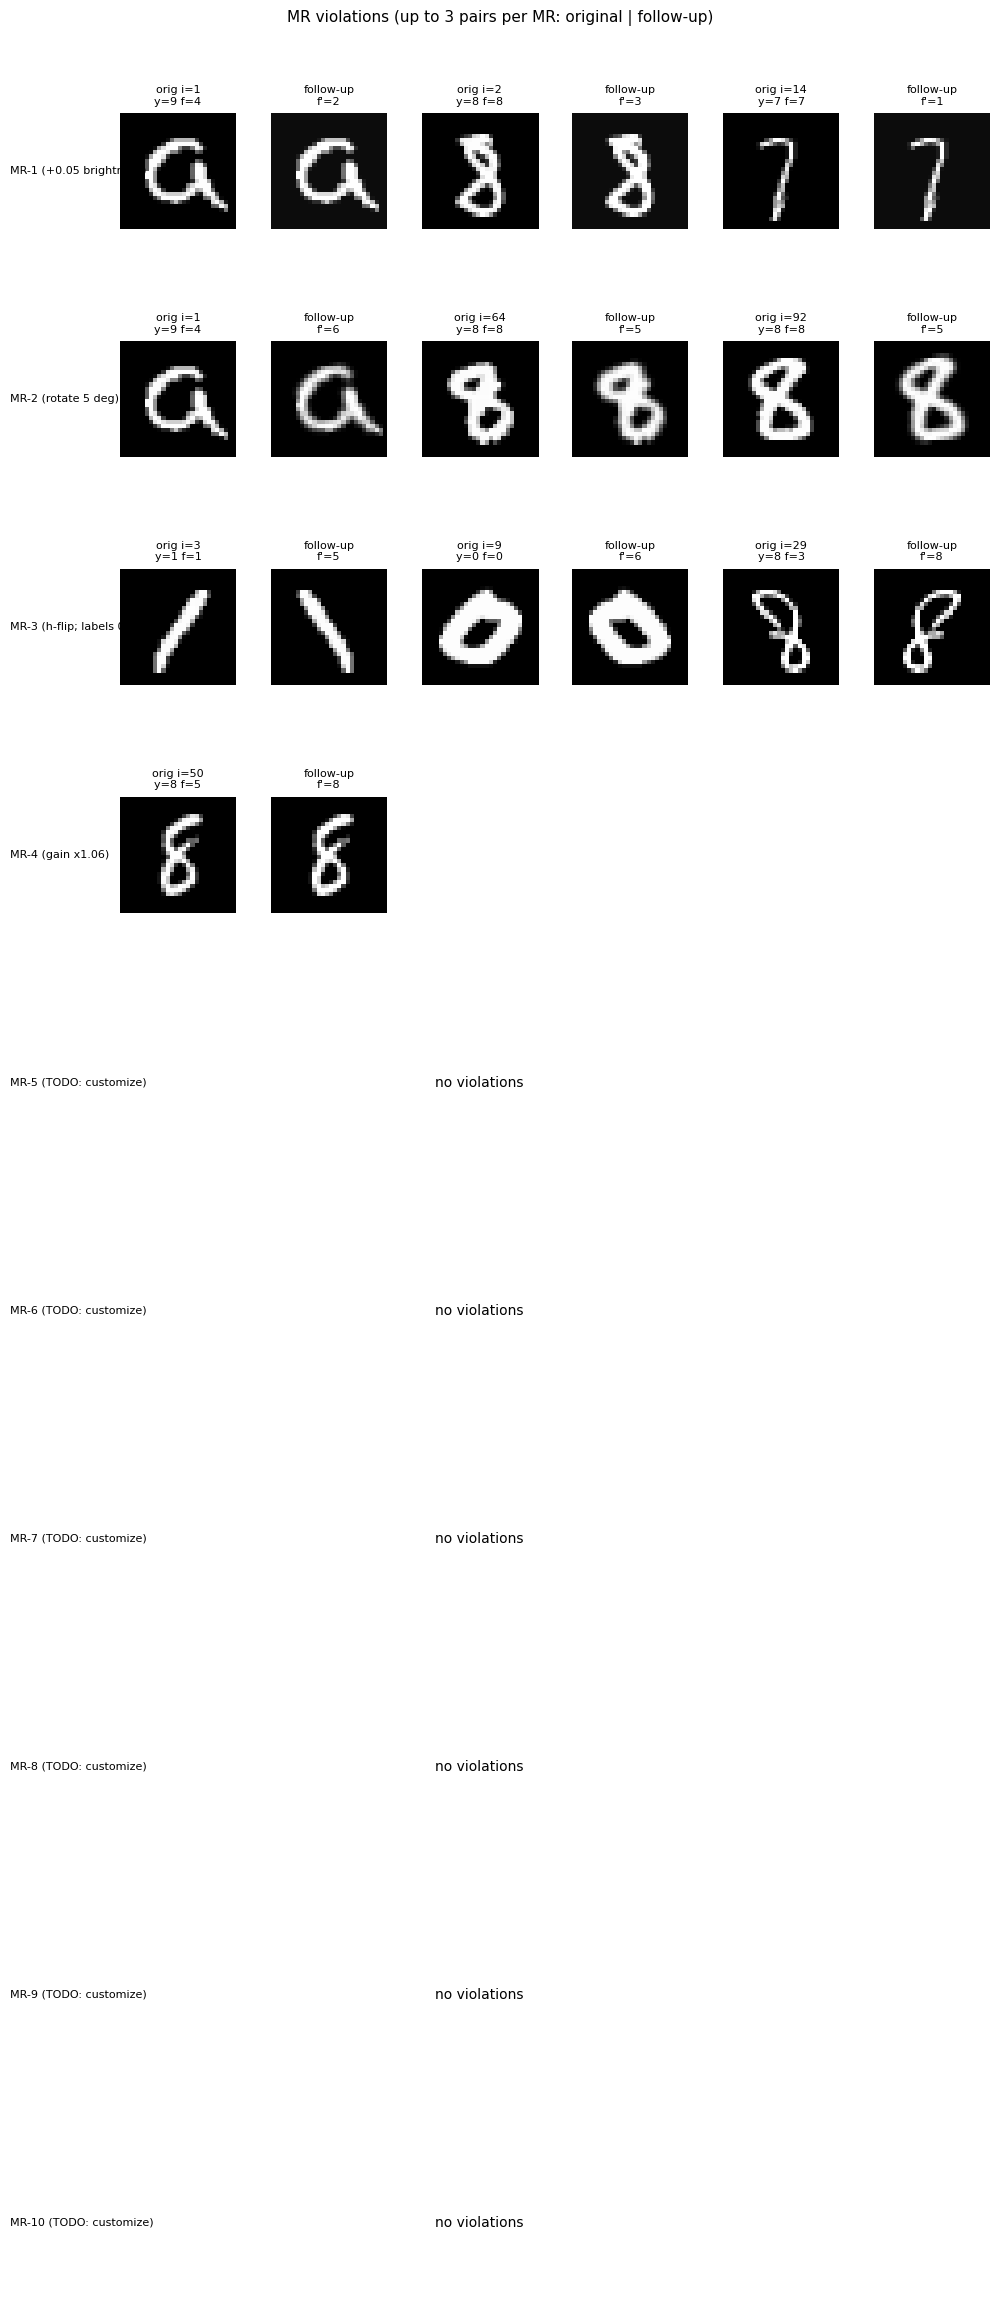

In [13]:
from typing import Callable, Optional

import matplotlib.pyplot as plt
import numpy as np

FollowupFn = Callable[[torch.Tensor], torch.Tensor]
EligibleFn = Callable[[int, int, torch.Tensor], bool]

NUM_MRS = 10


def eligible_all(_i: int, _y_true: int, _x: torch.Tensor) -> bool:
    return True


def eligible_symmetric_018(_i: int, y_true: int, _x: torch.Tensor) -> bool:
    """MR-3: only MNIST digits 0 / 1 / 8."""
    return y_true in (0, 1, 8)

# -----------------------------------------------------------------------------
# MR hyper-parameters (reuse in transformations and row titles)
# -----------------------------------------------------------------------------
MR1_DELTA = 0.05
MR2_ANGLE_DEG = 5.0
MR4_GAIN = 1.06


def followup_mr1(x: torch.Tensor) -> torch.Tensor:
    return torch.clamp(x.clone() + MR1_DELTA, 0.0, 1.0)


def followup_mr2(x: torch.Tensor) -> torch.Tensor:
    z = TF.rotate(
        x.clone(),
        angle=MR2_ANGLE_DEG,
        interpolation=InterpolationMode.BILINEAR,
        fill=0.0,
    )
    return torch.clamp(z, 0.0, 1.0)


def followup_mr3(x: torch.Tensor) -> torch.Tensor:
    return torch.flip(x.clone(), dims=[2])


def followup_mr4(x: torch.Tensor) -> torch.Tensor:
    return torch.clamp(x.clone() * MR4_GAIN, 0.0, 1.0)


def followup_mr5(x: torch.Tensor) -> torch.Tensor:
    # TODO(student): Implement the MR-5 follow-up mapping from your MR table below.
    # Identity shortcut: same tensor out so bulk checks trivially satisfy f(x) == f(x').
    return x


def followup_mr6(x: torch.Tensor) -> torch.Tensor:
    # TODO(student): Replace identity with MR-6 follow-up mapping when ready.
    return x


def followup_mr7(x: torch.Tensor) -> torch.Tensor:
    # TODO(student): Replace identity with MR-7 follow-up mapping when ready.
    return x


def followup_mr8(x: torch.Tensor) -> torch.Tensor:
    # TODO(student): Replace identity with MR-8 follow-up mapping when ready.
    return x


def followup_mr9(x: torch.Tensor) -> torch.Tensor:
    # TODO(student): Replace identity with MR-9 follow-up mapping when ready.
    return x


def followup_mr10(x: torch.Tensor) -> torch.Tensor:
    # TODO(student): Replace identity with MR-10 follow-up mapping when ready.
    return x


# -----------------------------------------------------------------------------
# Bulk sweep configuration: ONE entry per MR (10 rows). Plug in implementations:
#   - followup=None  -> MR skipped in aggregation (shows "no bulk MR" plot row)
#   - otherwise      -> callable x -> x' tested on each image passing eligible_fn
# MR-5..10 ship as identity shortcuts (return x) until you overwrite the TODO bodies.
# -----------------------------------------------------------------------------
BULK_MR_SLOTS: list[dict] = [
    {
        "title": f"MR-1 (+{MR1_DELTA:g} brightness)",
        "followup": followup_mr1,
        "eligible": eligible_all,
    },
    {
        "title": f"MR-2 (rotate {MR2_ANGLE_DEG:g} deg)",
        "followup": followup_mr2,
        "eligible": eligible_all,
    },
    {
        "title": "MR-3 (h-flip; labels 0/1/8)",
        "followup": followup_mr3,
        "eligible": eligible_symmetric_018,
    },
    {
        "title": f"MR-4 (gain x{MR4_GAIN:g})",
        "followup": followup_mr4,
        "eligible": eligible_all,
    },
    {"title": "MR-5 (TODO: customize)", "followup": followup_mr5, "eligible": eligible_all},
    {"title": "MR-6 (TODO: customize)", "followup": followup_mr6, "eligible": eligible_all},
    {"title": "MR-7 (TODO: customize)", "followup": followup_mr7, "eligible": eligible_all},
    {"title": "MR-8 (TODO: customize)", "followup": followup_mr8, "eligible": eligible_all},
    {"title": "MR-9 (TODO: customize)", "followup": followup_mr9, "eligible": eligible_all},
    {"title": "MR-10 (TODO: customize)", "followup": followup_mr10, "eligible": eligible_all},
]


def tensor_to_gray_imshow(ax, t: torch.Tensor, title: str) -> None:
    ax.imshow(t.squeeze().cpu().numpy(), cmap="gray", vmin=0.0, vmax=1.0)
    ax.set_title(title, fontsize=8)
    ax.axis("off")


assert len(BULK_MR_SLOTS) == NUM_MRS

N = len(test_images)
eligible = np.zeros(NUM_MRS, dtype=np.int64)
violations = np.zeros(NUM_MRS, dtype=np.int64)
vio_samples = [[] for _ in range(NUM_MRS)]  # tuples: idx, x, x', pred(x), pred(x'), y_true

correct_orig = 0
for i in range(N):
    x = test_images[i]
    y_true = int(test_labels[i].item())
    if predict_class(x) == y_true:
        correct_orig += 1
accuracy_orig = correct_orig / N

for mr_idx, slot in enumerate(BULK_MR_SLOTS):
    followup: Optional[FollowupFn] = slot["followup"]
    eligible_fn: EligibleFn = slot["eligible"]

    if followup is None:
        continue

    for i in range(N):
        x = test_images[i]
        y_true = int(test_labels[i].item())
        if not eligible_fn(i, y_true, x):
            continue
        eligible[mr_idx] += 1
        x_prime = followup(x)
        py, py_prime = predict_class(x), predict_class(x_prime)    # Metamorphic testing
        if py != py_prime:
            violations[mr_idx] += 1
            if len(vio_samples[mr_idx]) < 3:
                vio_samples[mr_idx].append((i, x, x_prime, py, py_prime, y_true))

print(f"Original-set accuracy: {accuracy_orig:.4f} ({correct_orig}/{N})\n")
print("Metamorphic violation rates (violations / eligible trials):")
for k in range(NUM_MRS):
    name = f"MR-{k + 1}"
    e_count = int(eligible[k])
    v_count = int(violations[k])
    if e_count == 0:
        print(f"  {name}: n/a (no evaluations -- stub OR no eligible inputs)")
    else:
        print(f"  {name}: {v_count}/{e_count} = {v_count / e_count:.4f}")

mr_titles = [str(s["title"]) for s in BULK_MR_SLOTS]

fig, axes = plt.subplots(NUM_MRS, 6, figsize=(10, 2.35 * NUM_MRS))
plt.subplots_adjust(left=0.12, right=0.99, top=0.96, bottom=0.02, hspace=0.45, wspace=0.3)

for row in range(NUM_MRS):
    pos = axes[row, 0].get_position()
    y_lab = pos.y0 + pos.height / 2
    slot = BULK_MR_SLOTS[row]
    stub_row = slot["followup"] is None

    fig.text(
        0.01,
        y_lab,
        mr_titles[row] + (" (stub)" if stub_row else ""),
        transform=fig.transFigure,
        fontsize=8,
        va="center",
        ha="left",
    )

    if stub_row:
        for c in range(6):
            axes[row, c].axis("off")
        axes[row, 2].text(
            0.5,
            0.5,
            "followup=None in slot",
            ha="center",
            va="center",
            fontsize=9,
            transform=axes[row, 2].transAxes,
        )
        continue

    samples = vio_samples[row]
    if not samples:
        for c in range(6):
            axes[row, c].axis("off")
        axes[row, 2].text(
            0.5,
            0.5,
            "no violations",
            ha="center",
            va="center",
            fontsize=10,
            transform=axes[row, 2].transAxes,
        )
        continue

    for j in range(3):
        if j < len(samples):
            idx, x0, x1, p0, p1, lab = samples[j]
            tensor_to_gray_imshow(axes[row, 2 * j], x0, f"orig i={idx}\ny={lab} f={p0}")
            tensor_to_gray_imshow(axes[row, 2 * j + 1], x1, f"follow-up\nf'={p1}")
        else:
            axes[row, 2 * j].axis("off")
            axes[row, 2 * j + 1].axis("off")

plt.suptitle("MR violations (up to 3 pairs per MR: original | follow-up)", fontsize=11, y=0.995)
plt.show()


## Closing takeaway

Metamorphic testing helps when a definitive **explicit oracle** is missing or too expensive to keep.

It focuses on **relations** between source and follow-up runs, not on one golden label per input.

**Why it scales**
- Strength usually comes from **many credible, domain-grounded MRs**.
- Together they support an argument for **test adequacy** where a single perfect oracle does not exist.

**Before you leave**
- Picture a project where “the correct output” is fuzzy or costly.
- Ask whether **several MRs in combination** could justify **sufficient testing** anyway.
